In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [49]:
df = pd.read_csv(r'C:\Users\User\Desktop\Проект CaseBridge\freelance_tasks_final - freelance_tasks_final.csv')
df.head()

,id,наименование_задачи,тип_задачи,технологический_стек,срок_выполнения_дней,цена_руб,ценовой_диапазон
0,1,Синхронизация CRM и 1С,Автоматизация и скрипты,Zapier+Python,14,7000,5 000–15 000 ₽
1,2,Приложение учёта финансов,Мобильное приложение,Flutter,31,33200,30 000–60 000 ₽
2,3,Приложение трекинга тренировок,Мобильное приложение,React Native+Redux,10,70000,60 000–120 000 ₽
3,4,Вёрстка личного кабинета,Вёрстка,HTML+CSS+BEM,12,3500,до 5 000 ₽
4,5,Каталог с корзиной на Flutter,Мобильное приложение,React Native+TS,40,69000,60 000–120 000 ₽


In [50]:
df.describe()

,id,срок_выполнения_дней,цена_руб
count,3000.000000,3000.000000,3000.000000
mean,1500.500000,13.062667,18362.000000
std,866.169729,11.737404,20184.316309
min,1.000000,1.000000,2000.000000
25%,750.750000,5.000000,6000.000000
50%,1500.500000,10.000000,10000.000000
75%,2250.250000,16.000000,20725.000000
max,3000.000000,60.000000,136500.000000


In [51]:
#ОЧИСТКА ЗНАЧЕНИЙ
print("Пропущенные значения")
print(df.isnull().sum())
print("\n Процент недостающих значений: ")
print((df.isnull().sum() / len(df) * 100).round(2) )

# Общие дубликаты
print("Полных дублирующихся строк:", df.duplicated().sum(),"\n")

print(df.dtypes)

df.shape

Пропущенные значения
id                      0
наименование_задачи     0
тип_задачи              0
технологический_стек    0
срок_выполнения_дней    0
цена_руб                0
ценовой_диапазон        0
dtype: int64

 Процент недостающих значений: 
id                      0.0
наименование_задачи     0.0
тип_задачи              0.0
технологический_стек    0.0
срок_выполнения_дней    0.0
цена_руб                0.0
ценовой_диапазон        0.0
dtype: float64
Полных дублирующихся строк: 0 

id                      int64
наименование_задачи       str
тип_задачи                str
технологический_стек      str
срок_выполнения_дней    int64
цена_руб                int64
ценовой_диапазон          str
dtype: object


(3000, 7)

<Axes: xlabel='цена_руб', ylabel='Count'>

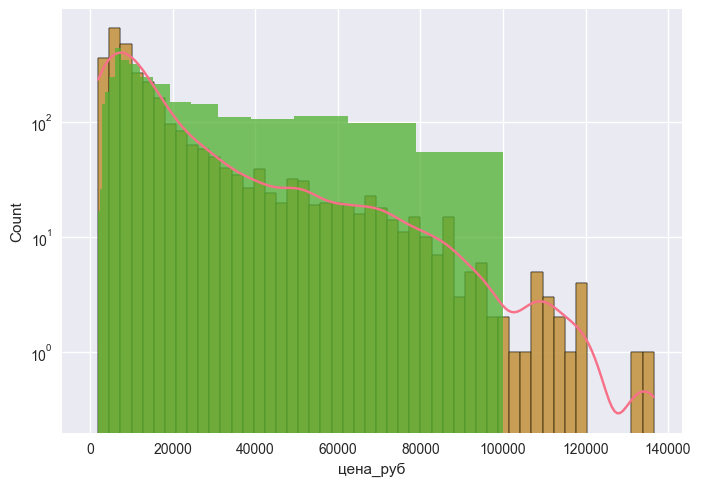

In [52]:
sns.histplot(data = df, x = "цена_руб", bins = 50, kde = True)

ax = sns.histplot(df['цена_руб'], bins = 50)
ax.set_yscale('log')

sns.histplot(df['цена_руб'], bins = np.logspace(0, 5, 50))

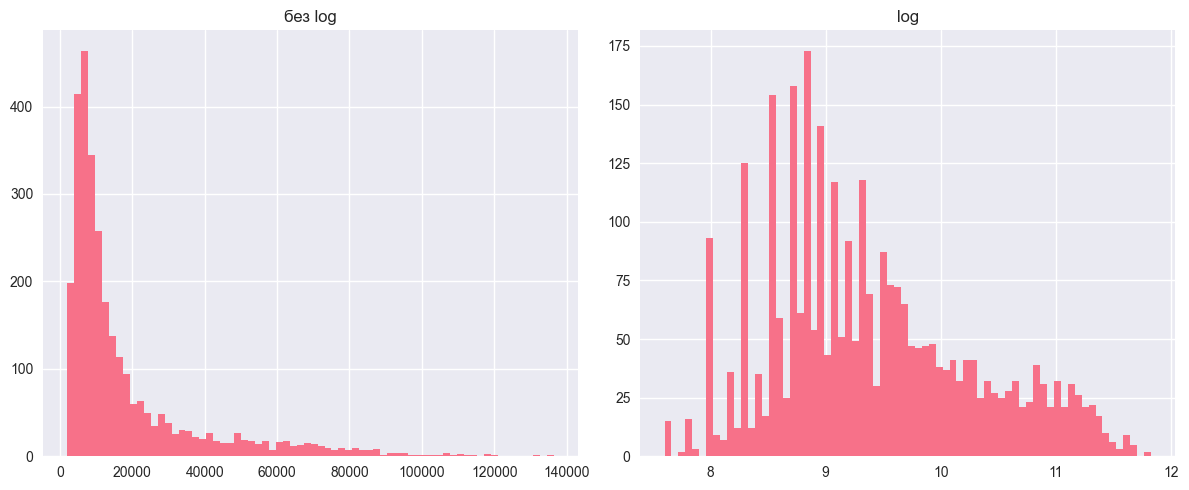

In [53]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
axes[0].hist(df["цена_руб"], bins = 70)
axes[1].hist(np.log(df["цена_руб"]), bins = 70)
axes[0].set_title("без log")
axes[1].set_title("log")
plt.tight_layout()
plt.show()

<Axes: ylabel='тип_задачи'>

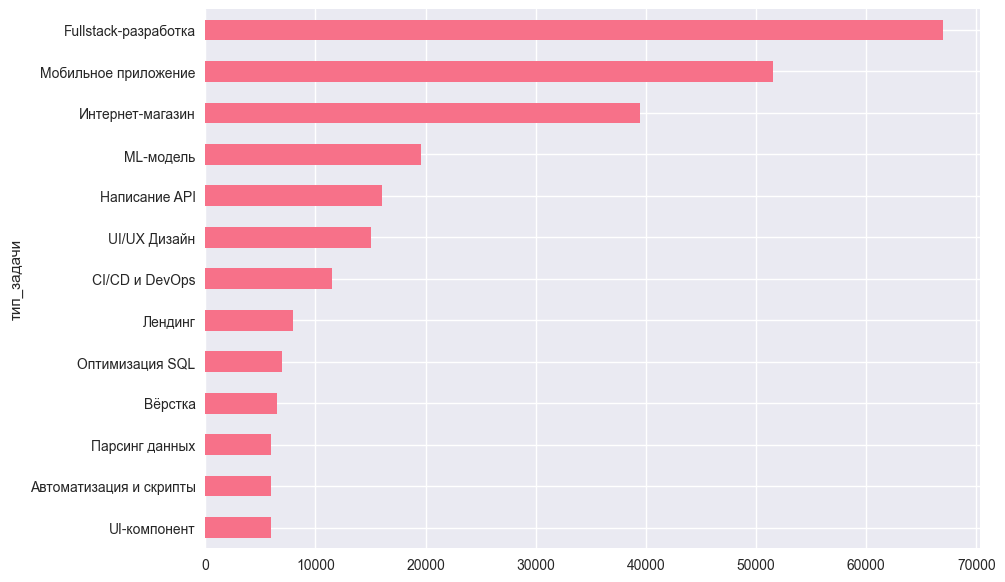

In [54]:
#медиана
med = df.groupby("тип_задачи")["цена_руб"].median()
med.sort_values().plot(kind="barh", figsize=(10, 7))


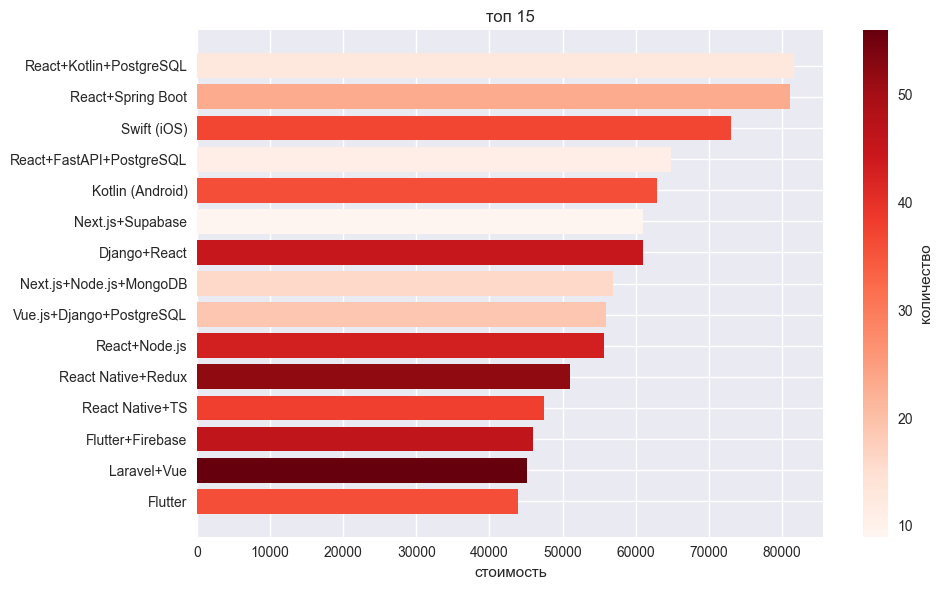

In [55]:
#df.groupby("технологический_стек")["цена_руб"].mean().sort_values(ascending=0).head(15)
group = df.groupby("технологический_стек")["цена_руб"].agg(["mean", "count"])
top15 = group.sort_values("mean", ascending=0).head(15)
top15 = top15.reset_index()

norm = matplotlib.colors.Normalize(vmin=top15["count"].min(), vmax=top15["count"].max())
palette = plt.colormaps["Reds"]
colors = palette(norm(top15["count"]))

fig, ax = plt.subplots(figsize = (10, 6))
ax.barh(y = range(len(top15)), width = top15["mean"], color = colors)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["технологический_стек"])
ax.invert_yaxis()

sm = plt.cm.ScalarMappable(norm=norm, cmap=palette)
fig.colorbar(sm, ax=ax, label="количество")

ax.set_xlabel("стоимость")
ax.set_title("топ 15")
plt.tight_layout()
plt.show()


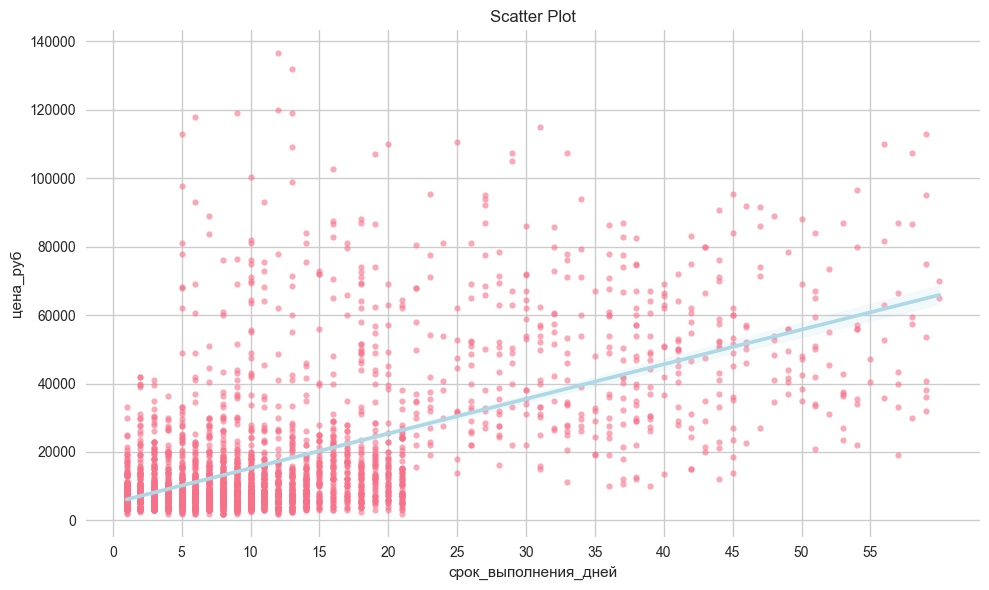

Correlation = 0.450
p-value = 2.3895e-149


In [85]:

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="срок_выполнения_дней",
    y="цена_руб",
    scatter_kws={"s": 20, "alpha": 0.6},
    line_kws={"color": "lightblue"}
)
plt.xticks(np.arange(0, 60, 5))
plt.title("Scatter Plot")
plt.tight_layout()
plt.show()

from scipy.stats import spearmanr

corr, p = spearmanr(df["срок_выполнения_дней"], df["цена_руб"])

print(f"Correlation = {corr:.3f}")
print(f"p-value = {p:.5}")

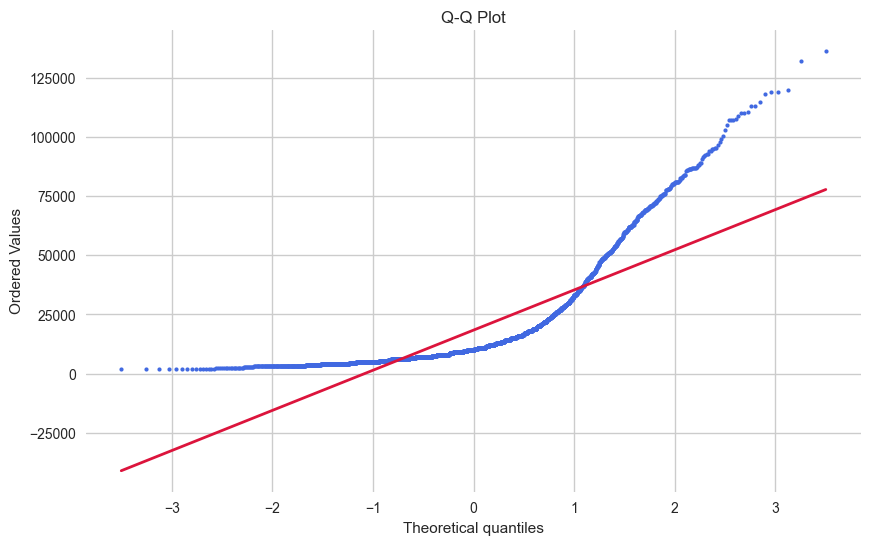

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

stats.probplot(df["цена_руб"], dist="norm", plot=ax)

ax.get_lines()[0].set_markersize(3)
ax.get_lines()[0].set_markerfacecolor("royalblue")
ax.get_lines()[0].set_markeredgecolor("royalblue")

ax.get_lines()[1].set_color("crimson")
ax.get_lines()[1].set_linewidth(2)

plt.title("Q-Q Plot")
plt.show()